### importing the main lib for this course

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json , os , joblib , pathlib

#### importing the lib for this session

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

### load the models config and some helper function

In [55]:
config = json.load(open('../configs/classification.json'))
base_path = pathlib.Path.cwd().parent.parent.parent
base_path

PosixPath('/home/aloha-zkaria/Hands-on-AI-Tutorial')

In [31]:
def load_dataset(path):
    """
    Args: path
    return : dataframe of the dataset
    """
    return pd.read_csv(base_path/path)

In [32]:
def detect_target(df):
    """fallback: last column"""
    return df.columns[-1]

#### loads the dataset and begin

In [33]:
df = load_dataset(config["datasets"][1]["path"])
print(f'loading dataset name : {config["datasets"][1]["name"]}')

loading dataset name : Heart Disease


In [34]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [35]:
df.shape

(1025, 14)

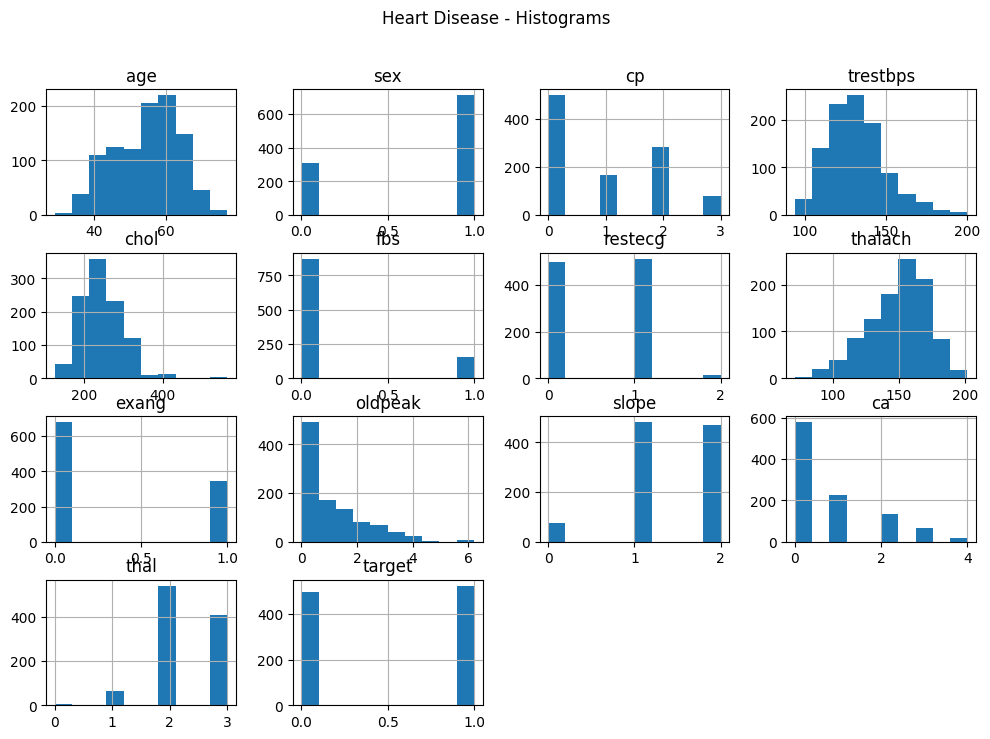

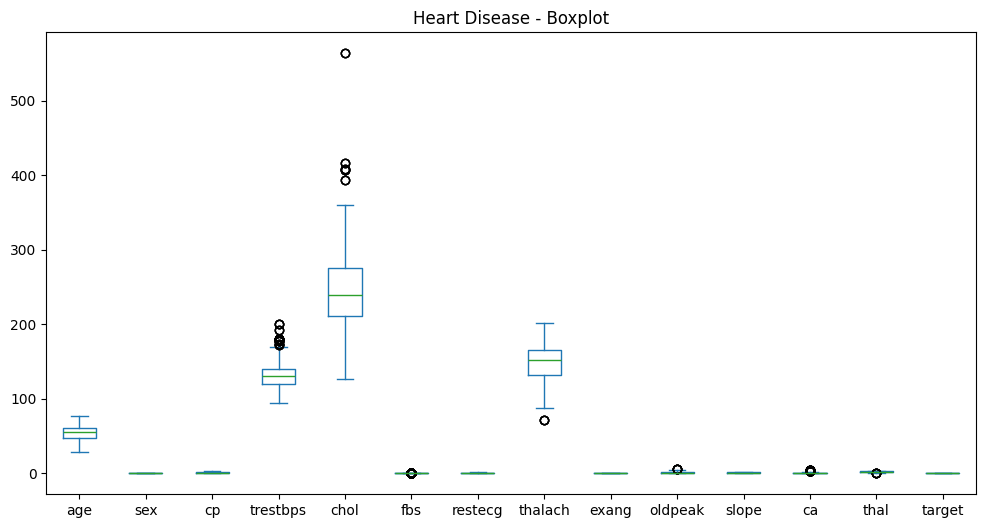

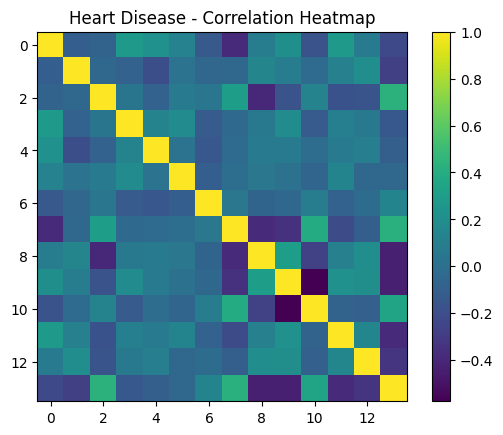

In [36]:
numeric_cols = df.select_dtypes(include="number").columns
name = config["datasets"][1]["name"]
if len(numeric_cols) > 0:
    # Histograms
    df[numeric_cols].hist(figsize=(12, 8))
    plt.suptitle(f"{name} - Histograms")
    plt.show()

    # Boxplot
    df[numeric_cols].plot(kind="box", figsize=(12, 6))
    plt.title(f"{name} - Boxplot")
    plt.show()

    # Correlation heatmap (basic)
    plt.imshow(df.corr(numeric_only=True))
    plt.colorbar()
    plt.title(f"{name} - Correlation Heatmap")
    plt.show()

else:
    print("⚠️ No numeric columns to plot.")

In [37]:
print("\n🔹 DESCRIBE (NUMERIC):")
df.describe()


🔹 DESCRIBE (NUMERIC):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [38]:
print("\n🔹 MEAN:")
df.mean(numeric_only=True)


🔹 MEAN:


age          54.434146
sex           0.695610
cp            0.942439
trestbps    131.611707
chol        246.000000
fbs           0.149268
restecg       0.529756
thalach     149.114146
exang         0.336585
oldpeak       1.071512
slope         1.385366
ca            0.754146
thal          2.323902
target        0.513171
dtype: float64

In [39]:
print("\n🔹 MEDIAN:")
df.median(numeric_only=True)


🔹 MEDIAN:


age          56.0
sex           1.0
cp            1.0
trestbps    130.0
chol        240.0
fbs           0.0
restecg       1.0
thalach     152.0
exang         0.0
oldpeak       0.8
slope         1.0
ca            0.0
thal          2.0
target        1.0
dtype: float64

In [40]:
print("\n🔹 STD:")
df.std(numeric_only=True)


🔹 STD:


age          9.072290
sex          0.460373
cp           1.029641
trestbps    17.516718
chol        51.592510
fbs          0.356527
restecg      0.527878
thalach     23.005724
exang        0.472772
oldpeak      1.175053
slope        0.617755
ca           1.030798
thal         0.620660
target       0.500070
dtype: float64

In [41]:
print("\n🔹 CORRELATION:")
df.corr(numeric_only=True)



🔹 CORRELATION:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


In [42]:
print(f"Check null value")
df.isnull().sum()

Check null value


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [43]:
print("Check duplication Value")
df.duplicated().sum()

Check duplication Value


723

In [44]:
target_candidates = [config["datasets"][1]["target"] , "Target"]
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    raise ValueError("Could not identify target")

Found target: 'target'


In [45]:
print("droping na value")
df = df.dropna(subset=[target_col]).reset_index(drop=True)

droping na value


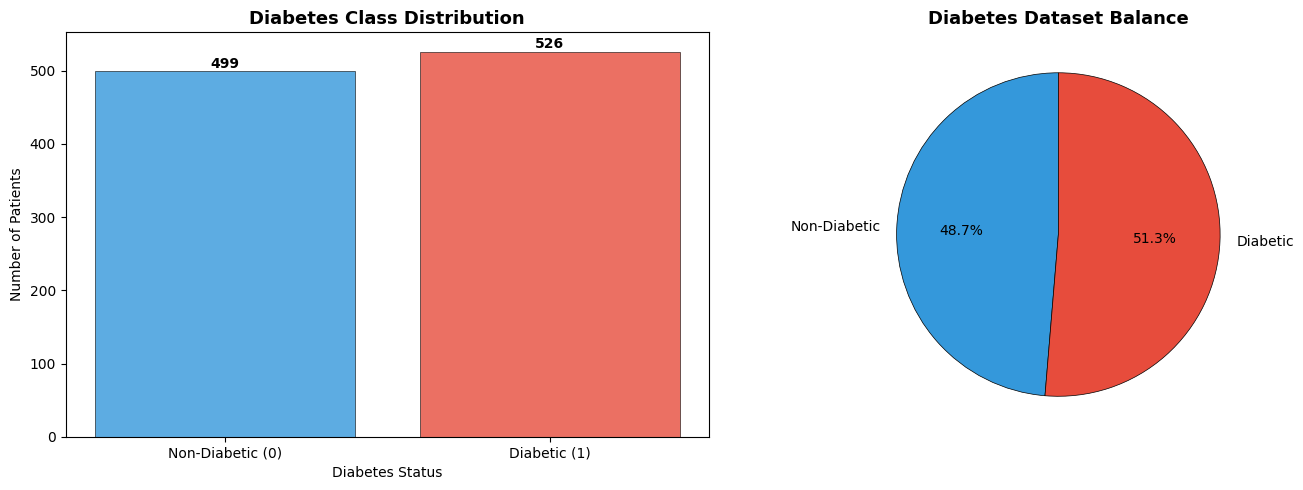

Dataset Context:
Total Patients: 1025
Non-Diabetic Cases: 499
Diabetic Cases: 526
Diabetes Rate: 51.32%

Healthcare Context:
WHO: Diabetes is one of the fastest growing chronic diseases worldwide.
Early prediction of diabetes can reduce severe complications and improve quality of life.
SDG 3: Ensure healthy lives and promote wellbeing for all at all ages.


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution plot
class_counts = df[target_col].value_counts().sort_index()

axes[0].bar(
    class_counts.index.astype(str),
    class_counts.values,
    color=['#3498db', '#e74c3c'],
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8
)

axes[0].set_title(
    'Diabetes Class Distribution',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xlabel('Diabetes Status')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])

# Add value labels
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart for class balance
axes[1].pie(
    class_counts.values,
    labels=['Non-Diabetic', 'Diabetic'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#3498db', '#e74c3c'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)

axes[1].set_title(
    'Diabetes Dataset Balance',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('diabetes_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Dataset context
print("Dataset Context:")
print(f"Total Patients: {len(df)}")
print(f"Non-Diabetic Cases: {(df[target_col] == 0).sum()}")
print(f"Diabetic Cases: {(df[target_col] == 1).sum()}")
print(f"Diabetes Rate: {(df[target_col].mean() * 100):.2f}%")

print("\nHealthcare Context:")
print("WHO: Diabetes is one of the fastest growing chronic diseases worldwide.")
print("Early prediction of diabetes can reduce severe complications and improve quality of life.")
print("SDG 3: Ensure healthy lives and promote wellbeing for all at all ages.")

### now lets start building the model

#### label encoder categories

In [47]:
le_dict = {}
df_model = df.copy()
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

In [48]:
df_model.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [49]:
X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

#### Split the Dataset

In [50]:
print("Imputing Missing value")
null_total = X.isnull().sum().sum()
if null_total > 0:
    print(f"\nImputing {null_total} missing values with median...")
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")

Imputing Missing value

Feature matrix: (1025, 13)


In [51]:
x_train , x_test , y_train , y_test = train_test_split(X ,y ,
            test_size=config['splits']['train_test_split']['test_size'],
            random_state=config['splits']['train_test_split']['random_state']
)

#### now creating the models pipeline

In [ ]:
MODEL_MAP = {
    "LogisticRegression": LogisticRegression,
    "KNeighborsClassifier": KNeighborsClassifier,
    "RandomForestClassifier": RandomForestClassifier,
    "XGBClassifier": XGBClassifier,
    "SVC":SVC
}

In [56]:
def build_models(config):
    models_config = config["models"]
    models = {}

    for name, model_info in models_config.items():
        algo_name = model_info["algorithm"]
        params = model_info.get("parameters", {})

        if algo_name not in MODEL_MAP:
            raise ValueError(f"Unknown model: {algo_name}")

        model_class = MODEL_MAP[algo_name]
        models[name] = model_class(**params)

    return models

In [57]:
models = build_models(config)

for name, model in models.items():
    print(f"{name} -> {model}")

Logistic Regression -> LogisticRegression(max_iter=1000, n_jobs=-1)
K-Nearest Neighbors Classifier -> KNeighborsClassifier(n_jobs=-1)
Random Forest Classifier -> RandomForestClassifier(max_depth=10, n_jobs=-1)
Support Vector Classifier -> SVC(coef0=0.001, gamma=0.1, max_iter=50)
XGBoost Classifier -> XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1

#### Start the training of the models

In [58]:
import time
results = {}
for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")

    t_start = time.time()

    # Train
    model.fit(x_train, y_train)

    # Predict
    y_pred = model.predict(x_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    elapsed = time.time() - t_start

    # Store results
    results[model_name] = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "time": elapsed,
        "predictions": y_pred
    }

    print(
        f"  -- RMSE: {rmse:.4f} | "
        f"MAE: {mae:.4f} | "
        f"R2: {r2:.4f} | "
        f"Time: {elapsed:.2f}s"
    )


Training: Logistic Regression
  -- RMSE: 0.4526 | MAE: 0.2049 | R2: 0.1805 | Time: 0.92s

Training: K-Nearest Neighbors Classifier
  -- RMSE: 0.5180 | MAE: 0.2683 | R2: -0.0732 | Time: 0.04s

Training: Random Forest Classifier
  -- RMSE: 0.1210 | MAE: 0.0146 | R2: 0.9415 | Time: 0.15s

Training: Support Vector Classifier


/home/aloha-zkaria/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  -- RMSE: 0.4526 | MAE: 0.2049 | R2: 0.1805 | Time: 0.01s

Training: XGBoost Classifier
  -- RMSE: 0.1210 | MAE: 0.0146 | R2: 0.9415 | Time: 0.39s


#### 6. Model Comparison & Selection¶

In [59]:
summary_rows = []

for model_name, res in results.items():
    summary_rows.append({
        "Model": model_name,
        "RMSE": f"{res['rmse']:.4f}",
        "MAE": f"{res['mae']:.4f}",
        "R2": f"{res['r2']:.4f}",
        "Time": f"{res['time']:.2f}s",
        "sort_val": res["r2"]
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("sort_val", ascending=False)
    .drop(columns=["sort_val"])
)

best_model_name = summary_df.iloc[0]["Model"]

print("MODEL COMPARISON")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)
print(f"\nBest model: {best_model_name}")

MODEL COMPARISON
                         Model   RMSE    MAE      R2  Time
      Random Forest Classifier 0.1210 0.0146  0.9415 0.15s
            XGBoost Classifier 0.1210 0.0146  0.9415 0.39s
           Logistic Regression 0.4526 0.2049  0.1805 0.92s
     Support Vector Classifier 0.4526 0.2049  0.1805 0.01s
K-Nearest Neighbors Classifier 0.5180 0.2683 -0.0732 0.04s

Best model: Random Forest Classifier


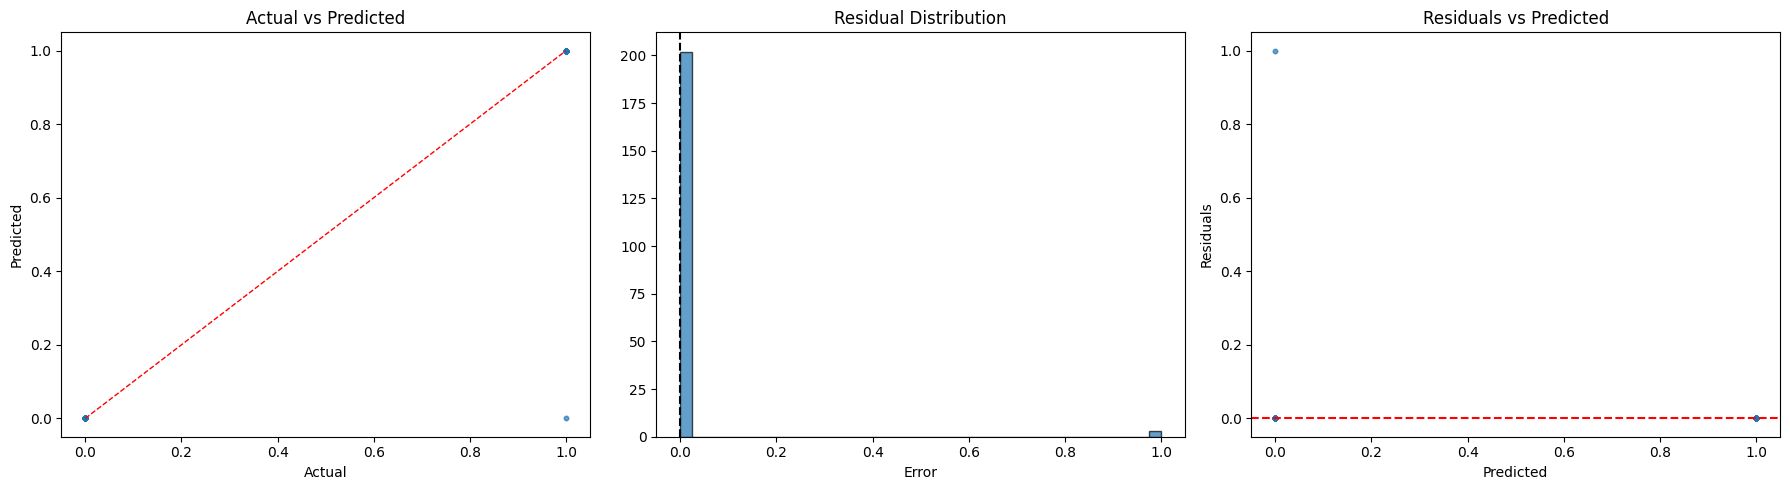

Mean residual: 0.015
Std residual:  0.120
MAE:           0.015


In [63]:
best_preds = results[best_model_name]["predictions"]
residuals = y_test - best_preds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_test, best_preds, alpha=0.3, s=10)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)

axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[1].hist(residuals, bins=40, alpha=0.7, edgecolor="black")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Error")
axes[2].scatter(best_preds, residuals, alpha=0.3, s=10)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_title("Residuals vs Predicted")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean residual: {np.mean(residuals):.3f}")
print(f"Std residual:  {np.std(residuals):.3f}")
print(f"MAE:           {np.mean(np.abs(residuals)):.3f}")

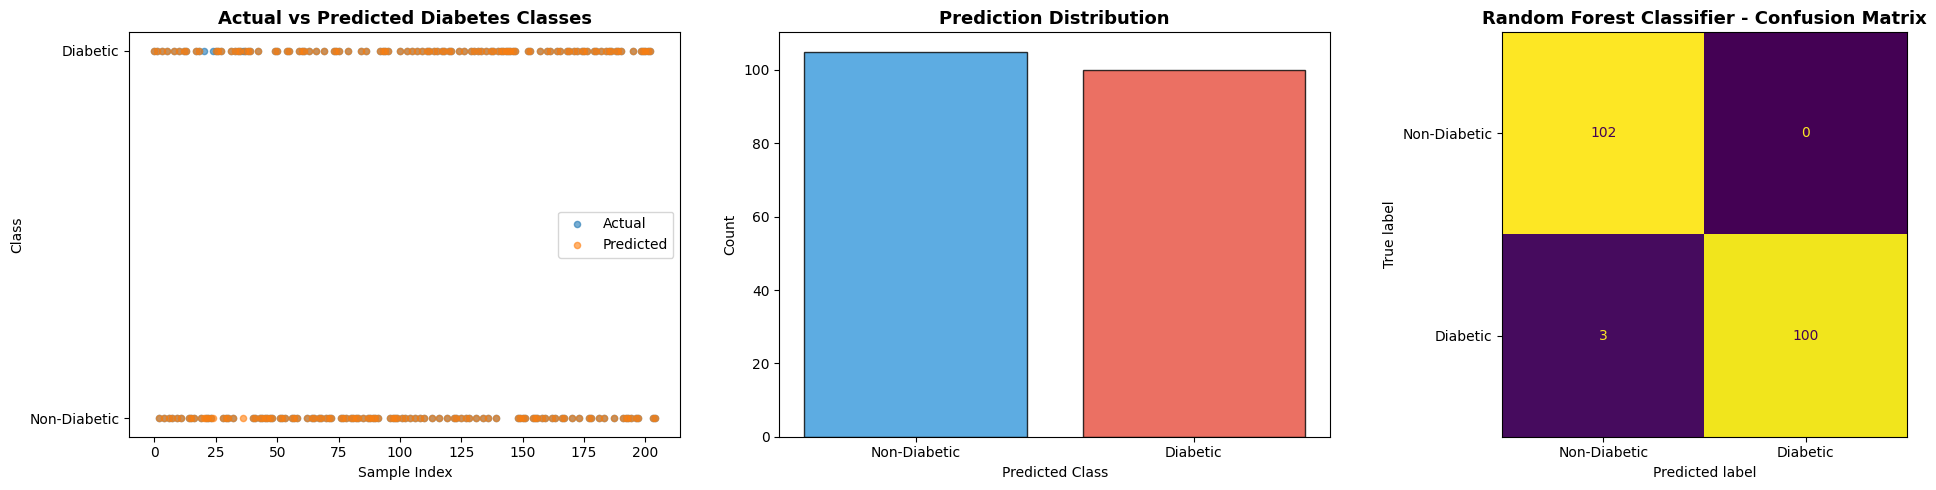

Best Model: Random Forest Classifier
Accuracy : 0.9854
Precision: 1.0000
Recall   : 0.9709
F1-Score : 0.9852


In [65]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Best model predictions
best_preds = results[best_model_name]["predictions"]
best_probs = results[best_model_name].get("probabilities", None)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].scatter(
    range(len(y_test)),
    y_test,
    alpha=0.6,
    label="Actual",
    s=20
)

axes[0].scatter(
    range(len(best_preds)),
    best_preds,
    alpha=0.6,
    label="Predicted",
    s=20
)

axes[0].set_title(
    "Actual vs Predicted Diabetes Classes",
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel("Sample Index")
axes[0].set_ylabel("Class")
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["Non-Diabetic", "Diabetic"])
axes[0].legend()
pred_counts = pd.Series(best_preds).value_counts().sort_index()

axes[1].bar(
    pred_counts.index.astype(str),
    pred_counts.values,
    color=['#3498db', '#e74c3c'],
    edgecolor='black',
    alpha=0.8
)

axes[1].set_title(
    "Prediction Distribution",
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Count")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Non-Diabetic", "Diabetic"])

cm = confusion_matrix(y_test, best_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot(ax=axes[2], colorbar=False)

axes[2].set_title(
    f"{best_model_name} - Confusion Matrix",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig("diabetes_model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

accuracy = accuracy_score(y_test, best_preds)
precision = precision_score(y_test, best_preds)
recall = recall_score(y_test, best_preds)
f1 = f1_score(y_test, best_preds)

print("=" * 50)
print(f"Best Model: {best_model_name}")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# ROC-AUC if probabilities exist
if best_probs is not None:
    auc = roc_auc_score(y_test, best_probs)
    print(f"ROC-AUC  : {auc:.4f}")

tn, fp, fn, tp = cm.ravel()


In [66]:
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

print("\nHealthcare Context:")
print("False Negatives are critical in diabetes prediction because")
print("undiagnosed diabetic patients may not receive early treatment.")
print("High Recall is important for reducing missed diabetes cases.")
print("SDG 3: Ensure healthy lives and promote wellbeing for all at all ages.")


Confusion Matrix Breakdown:
True Negatives : 102
False Positives: 0
False Negatives: 3
True Positives : 100

Healthcare Context:
False Negatives are critical in diabetes prediction because
undiagnosed diabetic patients may not receive early treatment.
High Recall is important for reducing missed diabetes cases.
SDG 3: Ensure healthy lives and promote wellbeing for all at all ages.


In [62]:
print("""
============================================================
DIABETES CLASSIFICATION SYSTEM ARCHITECTURE (PRODUCTION)
============================================================

1. DATA PIPELINE
   Data Sources:
     - Hospitals & Clinics
     - Electronic Health Records (EHR)
     - Laboratory Systems
     - Wearable / IoT Health Devices
     - Public Healthcare Datasets (CDC, WHO, Kaggle)

   Features Collected:
     - Glucose Level
     - Blood Pressure
     - BMI
     - Insulin Level
     - Age
     - Pregnancies
     - Skin Thickness
     - Diabetes Pedigree Function

   Ingestion Layer:
     - REST APIs
     - Batch ETL Pipelines
     - Real-time Streaming (Kafka / RabbitMQ)

   Storage:
     - Cloud Data Lake (S3 / GCS / Azure Blob)
     - Relational DB (PostgreSQL / MySQL)
     - Feature Store for ML-ready features

   Data Processing:
     - Missing value handling
     - Outlier detection
     - Feature scaling & encoding
     - Feature engineering pipeline

------------------------------------------------------------

2. MODEL TRAINING & SERVING
   ML Frameworks:
     - Scikit-learn
     - XGBoost / LightGBM
     - TensorFlow / PyTorch (optional deep learning)

   Model Registry:
     - MLflow / Weights & Biases / custom registry

   Deployment Options:
     - FastAPI / Flask REST API
     - Docker container deployment
     - Kubernetes autoscaling
     - Edge deployment for hospitals

   Predictions:
     - Diabetes Risk Classification
     - Risk Probability Score
     - High-risk patient identification
     - Explainable AI outputs (SHAP / Feature Importance)

   API Output Example:
     {
       "prediction": "Diabetic",
       "probability": 0.91,
       "risk_level": "High"
     }

------------------------------------------------------------

3. INTEGRATION POINTS
   Healthcare Systems:
     - Hospital Management Systems (HMS)
     - Electronic Medical Record (EMR) platforms
     - Telemedicine applications
     - Mobile healthcare apps

   Stakeholders:
     - Doctors & Medical Staff
     - Healthcare Providers
     - Insurance Companies
     - Government Health Authorities

   Use Cases:
     - Early diabetes screening
     - Preventive healthcare programs
     - Clinical decision support
     - Patient risk prioritization
     - Remote health monitoring

------------------------------------------------------------

4. GOVERNANCE & SECURITY
   Data Privacy:
     - HIPAA / GDPR compliance
     - Encryption at rest & in transit
     - Secure authentication & authorization

   Data Quality:
     - Validation rules for medical records
     - Missing data imputation
     - Anomaly & duplicate detection

   Bias & Fairness:
     - Monitor demographic bias
     - Evaluate fairness across age/gender groups
     - Avoid healthcare discrimination

   Explainability:
     - SHAP values
     - Feature importance visualization
     - Transparent prediction reasoning

   Ethics:
     - AI-assisted diagnosis only
     - Human doctor oversight required
     - Avoid fully automated medical decisions

------------------------------------------------------------

5. MONITORING & RETRAINING
   Model Monitoring:
     - Accuracy / Precision / Recall / F1
     - ROC-AUC tracking
     - Confusion Matrix monitoring

   Drift Detection:
     - Monitor feature distribution changes
     - Detect healthcare population drift

   Retraining Strategy:
     - Monthly / Quarterly retraining
     - Trigger retraining on major data shifts

   Observability:
     - Centralized logging
     - Metrics dashboards (Grafana / Prometheus)
     - Alerting system for model degradation

------------------------------------------------------------

6. BUSINESS & HEALTH IMPACT
   Benefits:
     - Early diabetes detection
     - Reduced healthcare costs
     - Improved patient outcomes
     - Faster clinical screening

   Global Healthcare Alignment:
     - WHO Noncommunicable Disease Prevention
     - SDG 3: Ensure healthy lives and wellbeing

============================================================
""")


DIABETES CLASSIFICATION SYSTEM ARCHITECTURE (PRODUCTION)

1. DATA PIPELINE
   Data Sources:
     - Hospitals & Clinics
     - Electronic Health Records (EHR)
     - Laboratory Systems
     - Wearable / IoT Health Devices
     - Public Healthcare Datasets (CDC, WHO, Kaggle)

   Features Collected:
     - Glucose Level
     - Blood Pressure
     - BMI
     - Insulin Level
     - Age
     - Pregnancies
     - Skin Thickness
     - Diabetes Pedigree Function

   Ingestion Layer:
     - REST APIs
     - Batch ETL Pipelines
     - Real-time Streaming (Kafka / RabbitMQ)

   Storage:
     - Cloud Data Lake (S3 / GCS / Azure Blob)
     - Relational DB (PostgreSQL / MySQL)
     - Feature Store for ML-ready features

   Data Processing:
     - Missing value handling
     - Outlier detection
     - Feature scaling & encoding
     - Feature engineering pipeline

------------------------------------------------------------

2. MODEL TRAINING & SERVING
   ML Frameworks:
     - Scikit-learn
     - XG